# Section 1. Install deps

In [1]:
!pip install pandas numpy gdown

# Section 2. Data access

In [2]:
import pandas as pd
import gdown
import ast

file_id = "1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O"

url = f"https://drive.google.com/uc?id={file_id}"

output = "processed_v2.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
texts = df["text"].apply(lambda x: ast.literal_eval(x)["clean"])

df.head(5)

Downloading...
From: https://drive.google.com/uc?id=1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O
To: /content/processed_v2.csv
100%|██████████| 4.21M/4.21M [00:00<00:00, 24.2MB/s]


,title,text,category_id
0,Івано-Франківський драмтеатр знайшов архівні д...,{'clean': 'на пресконференції гендиректор-худо...,0
1,Премія Олеся Гончара оголосила номінантів,{'clean': 'Держмистецтв. Цьогоріч на здобуття ...,0
2,Біографічний фільм «Я граю Роккі» вийде у лист...,{'clean': ' The Hollywood Reporter. Стрічка ві...,0
3,Netflix підписав угоду на трансляцію фільмів S...,"{'clean': 'Deadline. Зазначається, що найважли...",0
4,На Венеційській бієнале Україну представить ск...,{'clean': 'розповіли учасники Венеційської біє...,0


# Section 3. Corpus filtering / preprocessing checks

In [3]:
import pandas as pd
import re


before_count = len(df)

def clean_processed_text(text_item):
    if isinstance(text_item, list):
        text = " ".join(text_item)
    else:
        text = str(text_item)

    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

texts_cleaned = texts.apply(clean_processed_text)
texts_cleaned = texts_cleaned[texts_cleaned.str.len() > 0]

after_count = len(df)

print("Кількість документів ДО фільтрації:", before_count)
print("Кількість документів ПІСЛЯ фільтрації:", after_count)

Кількість документів ДО фільтрації: 837
Кількість документів ПІСЛЯ фільтрації: 837


# Section 4. Vectorizer setup

In [4]:
ukr_stopwords = ['а', 'аби', 'абиде', 'абиким', 'абикого', 'абиколи', 'абикому', 'абикуди', 'абихто', 'абичий', 'абичийого', 'абичийому', 'абичим',
                 'абичию', 'абичия', 'абичиє', 'абичиєму', 'абичиєю', 'абичиєї', 'абичиї', 'абичиїй', 'абичиїм', 'абичиїми', 'абичиїх', 'абичого',
                 'абичому', 'абищо', 'абияка', 'абияке', 'абиякий', 'абияким', 'абиякими', 'абияких', 'абиякого', 'абиякому', 'абиякою', 'абиякої',
                 'абияку', 'абиякі', 'абиякій', 'абиякім', 'або', 'абощо', 'авжеж', 'авось', 'ага', 'ад', 'адже', 'аж', 'ажень', 'аз', 'ай', 'але',
                 'ало', 'амінь', 'ант', 'ану', 'ані', 'аніде', 'аніж', 'анізащо', 'аніким', 'анікого', 'анікогісінько', 'аніколи', 'анікому', 'аніскільки',
                 'аніхто', 'анічим', 'анічого', 'анічогісінько', 'анічому', 'аніщо', 'аніяка', 'аніяке', 'аніякий', 'аніяким', 'аніякими', 'аніяких', 'аніякого',
                 'аніякому', 'аніякою', 'аніякої', 'аніяку', 'аніякі', 'аніякій', 'аніякім', 'аніякісенька', 'аніякісеньке', 'аніякісенький', 'аніякісеньким',
                 'аніякісенькими', 'аніякісеньких', 'аніякісенького', 'аніякісенькому', 'аніякісенькою', 'аніякісенької', 'аніякісеньку', 'аніякісенькі', 'аніякісенькій',
                 'аніякісенькім', 'аніякісінька', 'аніякісіньке', 'аніякісінький', 'аніякісіньким', 'аніякісінькими', 'аніякісіньких', 'аніякісінького', 'аніякісінькому',
                 'аніякісінькою', 'аніякісінької', 'аніякісіньку', 'аніякісінькі', 'аніякісінькій', 'аніякісінькім', 'ат', 'ато', 'атож', 'ау', 'ах', 'ач', 'ачей',
                 'аякже', 'б', 'ба', 'багато', 'багатьма', 'багатьом', 'багатьох', 'баз', 'бай', 'бат', 'бах', 'бац', 'баш', 'бе', 'беж', 'без', 'безперервно', 'бел',
                 'бер', 'би', 'бир', 'бич', 'близько', 'близько від', 'бо', 'бов', 'бод', 'бодай', 'боз', 'бош', 'був', 'буває', 'буде', 'будем', 'будемо', 'будете',
                 'будеш', 'буду', 'будуть', 'будь', 'будь ласка', 'будьмо', 'будьте', 'була', 'були', 'було', 'бути', 'бух', 'буц', 'буцім', 'буцімто', 'бі', 'біб',
                 'більш', 'більше', 'біля', 'в', 'в бік', 'в залежності від', 'в міру', 'в напрямі до', 'в порівнянні з', 'в процесі', 'в результаті', 'в ролі', 'в силу',
                 'в сторону', 'в супроводі', 'в ході', "в ім'я", 'в інтересах', 'вад', 'важлива', 'важливе', 'важливий', 'важливі', 'вак', 'вам', 'вами', 'ван', 'вас',
                 'ват', 'ваш', 'ваша', 'ваше', 'вашим', 'вашими', 'ваших', 'вашого', 'вашому', 'вашою', 'вашої', 'вашу', 'ваші', 'вашій', 'вашім', 'ввесь', 'вві', 'вгору',
                 'вдалині', 'вед', 'верх', 'весь', 'вех', 'вже', 'вздовж', 'ви', 'виз', 'вис', 'височині', 'вище ', 'вйо', 'власне', 'властиво', 'вміти', 'внаслідок', 'вниз',
                 'внизу', 'во', 'вон', 'вона', 'вони', 'воно', 'восьмий', 'вперед', 'вподовж', 'впоперек', 'впритиск', 'впритул', 'впродовж', 'впрост', 'все', 'всередині',
                 'всею', 'вслід', 'всупереч', 'всього', 'всьому', 'всю', 'всюди', 'вся', 'всяк', 'всяка', 'всяке', 'всякий', 'всяким', 'всякими', 'всяких', 'всякого', 'всякому',
                 'всякою', 'всякої', 'всяку', 'всякі', 'всякій', 'всякім', 'всі', 'всій', 'всіляка', 'всіляке', 'всілякий', 'всіляким', 'всілякими', 'всіляких', 'всілякого',
                 'всілякому', 'всілякою', 'всілякої', 'всіляку', 'всілякі', 'всілякій', 'всілякім', 'всім', 'всіма', 'всіх', 'всією', 'всієї', 'втім', 'ві', 'віг', 'від',
                 'від імені', 'віддалік від', 'відколи', 'відносно', 'відповідно', 'відповідно до', 'відсотків', 'відтепер', 'відтоді', 'він', 'вісім', 'вісімнадцятий',
                 'вісімнадцять', 'віт', 'віф', 'віх', 'віц', 'віщо', 'віщось', 'г', 'га', 'гав', 'гаразд', 'ге', 'гез', 'гем', 'геп', 'гет', 'геть', 'гех', 'ги', 'гик', 'гир',
                 'гич', 'гм', 'го', 'говорив', 'гог', 'гоп', 'гоц', 'гу', 'гуп', 'д', 'да', 'давай', 'давати', 'давно', 'далеко', 'далеко від', 'далі', 'даром', 'два', 'двадцятий',
                 'двадцять', 'дванадцятий', 'дванадцять', 'двох', 'дві', 'де', "дев'ятий", "дев'ятнадцятий", "дев'ятнадцять", "дев'ять", 'дедалі', 'деким', 'декого', 'деколи', 'декому', 'декотра', 'декотре', 'декотрий', 'декотрим', 'декотрими', 'декотрих', 'декотрого', 'декотрому', 'декотрою', 'декотрої', 'декотру', 'декотрі', 'декотрій', 'декотрім', 'декілька', 'декільком', 'декількома', 'декількох', 'декім', 'десь', 'десятий', 'десять', 'дехто', 'дечий', 'дечийого', 'дечийому', 'дечим', 'дечию', 'дечия', 'дечиє', 'дечиєму', 'дечиєю', 'дечиєї', 'дечиї', 'дечиїй', 'дечиїм', 'дечиїми', 'дечиїх', 'дечого', 'дечому', 'дечім', 'дещо', 'деяка', 'деяке', 'деякий', 'деяким', 'деякими', 'деяких', 'деякого', 'деякому', 'деякою', 'деякої', 'деяку', 'деякі', 'деякій', 'деякім', 'деінде', 'для', 'до', 'добре', 'довго', 'довкола', 'довкіл', 'дог', 'доки', 'допоки', 'допіру', 'досить', 'досі', 'дотепер', 'доти', 'другий', 'друго', 'дуже', 'дякую', 'дійсно', 'діл', 'е', 'еге', 'еж', 'ей', 'ерг', 'ест', 'ет', 'ех', 'еч', 'ж', 'же', 'жоден', 'жодна', 'жодне', 'жодний', 'жодним', 'жодними', 'жодних', 'жодного', 'жодному', 'жодною', 'жодної', 'жодну', 'жодні', 'жодній', 'жоднім', 'жоднісінька', 'жоднісіньке', 'жоднісінький', 'жоднісіньким', 'жоднісінькими', 'жоднісіньких', 'жоднісінького', 'жоднісінькому', 'жоднісінькою', 'жоднісінької', 'жоднісіньку', 'жоднісінькі', 'жоднісінькій', 'жоднісінькім', 'жуз', 'з', 'з метою', 'з нагоди', 'з приводу', 'з розрахунку на', 'з-за', 'з-над', 'з-перед', 'з-поза', 'з-поміж', 'з-понад', 'з-поперед', 'з-посеред', 'з-проміж', 'з-під', 'з-серед', 'за', 'за винятком', 'за допомогою', 'за посередництвом', 'за рахунок', 'завгодно', 'завдяки', 'завжди', 'завше', 'задля', 'зазвичай', 'зайнята', 'зайнятий', 'зайнято', 'зайняті', 'залежно', 'залежно від', 'замість', 'занадто', 'заради', 'зараз', 'зас', 'зате', 'збоку', 'збоку від', 'зважаючи на', 'зверх ', 'зверху', 'звичайно', 'звиш', 'звідки', 'звідкилясь', 'звідкись', 'звідкіль', 'звідкіля', 'звідкілясь', 'звідси', 'звідсіль', 'звідсіля', 'звідти', 'звідтіль', 'звідтіля', 'звідусюди', 'звідусіль', 'звідціля', 'згідно з', 'здається', 'здовж', 'зем', 'зет', 'ззаду', 'зиз', 'зик', 'значить', 'знову', 'зо', 'зовсім', 'зсередини', 'зух', 'зі', 'зіс', 'и', 'ич', 'й', 'ймовірно', 'йно', 'йо', 'його', 'йой', 'йол', 'йому', 'йор', 'йот', 'йох', 'к', 'каже', 'каз', 'кар', 'каф', 'ках', 'ке', 'кед', 'кет', 'кеш', 'кив', 'кий', 'кил', 'ким', 'кимось', 'кимсь', 'ких', 'киш', 'коб', 'коби', 'кого', 'когось', 'кожен', 'кожна', 'кожне', 'кожний', 'кожним', 'кожними', 'кожних', 'кожного', 'кожному', 'кожною', 'кожної', 'кожну', 'кожні', 'кожній', 'кожнім', 'кожнісінька', 'кожнісіньке', 'кожнісінький', 'кожнісіньким', 'кожнісінькими', 'кожнісіньких', 'кожнісінького', 'кожнісінькому', 'кожнісінькою', 'кожнісінької', 'кожнісіньку', 'кожнісінькі', 'кожнісінькій', 'кожнісінькім', 'коли', 'колись', 'коло', 'кому', 'комусь', 'котра', 'котрась', 'котре', 'котресь', 'котрий', 'котрийсь', 'котрим', 'котрими', 'котримись', 'котримось', 'котримсь', 'котрих', 'котрихось', 'котрихсь', 'котрого', 'котрогось', 'котрому', 'котромусь', 'котрою', 'котроюсь', 'котрої', 'котроїсь', 'котру', 'котрусь', 'котрі', 'котрій', 'котрійсь', 'котрім', 'котрімсь', 'котрісь', 'коц', 'коч', 'коштом', 'край', 'краще', 'кру', 'круг', 'кругом', 'крю', 'кря', 'крізь', 'крім', 'куди', 'кудись', 'кудою', 'кілька', 'кільком', 'кількома', 'кількох', 'кім', 'кімось', 'кімсь', 'кінець', 'л', 'лаж', 'лап', 'лас', 'лат', 'ле', 'ледве', 'ледь', 'лет', 'лиш', 'лише', 'лишень', 'лум', 'луп', 'лут', 'льє', 'люди', 'людина', 'ля', 'лі', 'ліворуч від', 'лік', 'лім', 'м', 'мабуть', 'майже', 'мало', 'мати', 'мац', 'ме', 'меж', 'мене', 'менше', 'мені', 'мерсі', 'мет', 'мжа', 'ми', 'мимо ', 'миру', 'мит', 'мною', 'мо', 'мов', 'мовби', 'мовбито', 'могла', 'могли', 'могло', 'мого', 'могти', 'мож', 'може', 'можем', 'можемо', 'можете', 'можеш', 'можна', 'можу', 'можуть', 'можіть', 'мой', 'мол', 'мою', 'моя', 'моє', 'моєму', 'моєю', 'моєї', 'мої', 'моїй', 'моїм', 'моїми', 'моїх', 'му', 'мі', 'міг', 'між', 'мій', 'мільйонів', 'н', 'на', 'на адресу', 'на базі', 'на благо', 'на випадок', 'на відміну від', 'на засадах', 'на знак', 'на зразок', 'на користь', 'на кшталт', 'на межі', 'на основі', 'на противагу', 'на підставі', 'на честь', 'на чолі', 'на ґрунті', 'навколо', 'навкруг', 'навкруги ', 'навкіл', 'навпаки', 'навперейми', 'навпроти', 'навіть', 'навіщо', 'навіщось', 'нагорі', 'над', 'надо', 'надовкола', 'надокола', 'наді', 'назавжди', 'назад', 'назустріч', 'най', 'найбільш', 'нам', 'нами', 'наоколо ', 'наокруг ', 'наокруги ', 'наокіл', 'наперед', 'напередодні', 'напереді', 'наперекір', 'напереріз', 'наприкінці', 'напроти', 'нарешті', 'нарівні з', 'нас', 'насеред', 'насподі', 'наспід', 'настрічу', 'насупроти', 'насупротив ', 'нате', 'наче', 'начеб', 'начебто', 'наш', 'наша', 'наше', 'нашим', 'нашими', 'наших', 'нашого', 'нашому', 'нашою', 'нашої', 'нашу', 'наші', 'нашій', 'нашім', 'не', 'не до', 'не можна', 'неабичим', 'неабичого', 'неабичому', 'неабищо', 'небагато', 'небагатьма', 'небагатьом', 'небагатьох', 'небудь', 'невважаючи', 'невже', 'недалеко', 'недалеко від', 'неж', 'незалежно від', 'незважаючи', 'незважаючи на', 'ней', 'немає', 'немов', 'немовби', 'немовбито', 'неначе', 'неначебто', 'неподалеку', 'неподалеку від', 'неподалечку', 'неподалечку від', 'неподалік', 'неподалік від', 'нерідко', 'нех', 'нехай', 'нещодавно', 'нею', 'неї', 'нижче', 'низько', 'ник', 'ним', 'ними', 'них', 'нич', 'но', 'ну', 'нуг', 'нуд', 'нум', 'нумо', 'нумте', 'ньо', 'нього', 'ньому', 'ню', 'нюх', 'ня', 'няв', 'ні', 'ніби', 'ніби-то', 'нібито', 'ніде', 'ніж', 'нізащо', 'нізвідки', 'нізвідкіля', 'ній', 'ніким', 'нікого', 'нікогісінько', 'ніколи', 'нікому', 'нікотра', 'нікотре', 'нікотрий', 'нікотрим', 'нікотрими', 'нікотрих', 'нікотрого', 'нікотрому', 'нікотрою', 'нікотрої', 'нікотру', 'нікотрі', 'нікотрій', 'нікотрім', 'нікуди', 'нім', 'нінащо', 'ніскільки', 'ніт', 'ніхто', 'нічий', 'нічийна', 'нічийне', 'нічийний', 'нічийним', 'нічийними', 'нічийних', 'нічийного', 'нічийному', 'нічийною', 'нічийної', 'нічийну', 'нічийні', 'нічийній', 'нічийнім', 'нічийого', 'нічийому', 'нічим', 'нічию', 'нічия', 'нічиє', 'нічиєму', 'нічиєю', 'нічиєї', 'нічиї', 'нічиїй', 'нічиїм', 'нічиїми', 'нічиїх', 'нічого', 'нічому', 'ніщо', 'ніяк', 'ніяка', 'ніяке', 'ніякий', 'ніяким', 'ніякими', 'ніяких', 'ніякого', 'ніякому', 'ніякою', 'ніякої', 'ніяку', 'ніякі', 'ніякій', 'ніякім', 'ніякісінька', 'ніякісіньке', 'ніякісінький', 'ніякісіньким', 'ніякісінькими', 'ніякісіньких', 'ніякісінького', 'ніякісінькому', 'ніякісінькою', 'ніякісінької', 'ніякісіньку', 'ніякісінькі', 'ніякісінькій', 'ніякісінькім', 'о', 'об', 'обабіч', 'обаполи', 'обидва', 'обр', 'обік', 'обіруч', 'обіч', 'ов', 'од', 'один', 'одинадцятий', 'одинадцять', 'одна', 'однак', 'одначе', 'одне', 'одним', 'одними', 'одних', 'одно', 'одного', 'одного разу', 'одному', 'одною', 'одної', 'одну', 'одні', 'одній', 'однім', 'однією', 'однієї', 'ож', 'ой', 'окрай', 'окроме', 'округ', 'округи', 'окрім', 'окіл', 'ом', 'он', 'онде', 'онно', 'оно', 'оподаль', 'оподаль від', 'оподалік', 'оподалік від', 'опостін', 'опостінь', 'опроче', 'опріч', 'опріче', 'опісля', 'осе', 'оскільки', 'особливо', 'осторонь', 'ось', 'осісьо', 'от', 'ота', 'отак', 'отака', 'отаке', 'отакий', 'отаким', 'отакими', 'отаких', 'отакого', 'отакому', 'отакою', 'отакої', 'отаку', 'отакі', 'отакій', 'отакім', 'отакісінька', 'отакісіньке', 'отакісінький', 'отакісіньким', 'отакісінькими', 'отакісіньких', 'отакісінького', 'отакісінькому', 'отакісінькою', 'отакісінької', 'отакісіньку', 'отакісінькі', 'отакісінькій', 'отакісінькім', 'отам', 'оте', 'отже', 'отим', 'отими', 'отих', 'ото', 'отого', 'отож', 'отой', 'отому', 'отою', 'отої', 'отсе', 'оттак', 'отто', 'оту', 'отут', 'оті', 'отій', 'отім', 'отією', 'отієї', 'ох', 'оце', 'оцей', 'оцим', 'оцими', 'оцих', 'оцього', 'оцьому', 'оцю', 'оця', 'оці', 'оцій', 'оцім', 'оцією', 'оцієї', 'п', "п'я", "п'ятий", "п'ятнадцятий", "п'ятнадцять", "п'ять", 'па', 'пад', 'пак', 'пек', 'перед', 'передо', 'переді', 'перетака', 'перетаке', 'перетакий', 'перетаким', 'перетакими', 'перетаких', 'перетакого', 'перетакому', 'перетакою', 'перетакої', 'перетаку', 'перетакі', 'перетакій', 'перетакім', 'перший', 'пиж', 'плі', 'по', 'поблизу', 'побік', 'побіля', 'побіч', 'поверх', 'повз', 'повздовж', 'повинно', 'повище', 'повсюди', 'повсюдно', 'подаль від', 'подалі від', 'подекуди', 'подеяка', 'подеяке', 'подеякий', 'подеяким', 'подеякими', 'подеяких', 'подеякого', 'подеякому', 'подеякою', 'подеякої', 'подеяку', 'подеякі', 'подеякій', 'подеякім', 'подовж', 'подібно до', 'поз', 'поза', 'позад', 'позаду', 'позата', 'позате', 'позатим', 'позатими', 'позатих', 'позатого', 'позатой', 'позатому', 'позатою', 'позатої', 'позату', 'позаті', 'позатій', 'позатім', 'позатією', 'позатієї', 'позаяк', 'поздовж', 'поки', 'покрай', 'покіль', 'помежи', 'помимо',
                 'поміж', 'помість', 'понад', 'понадо', 'понаді', 'понижче', 'пообіч', 'поодаль від', 'поодалік від', 'поперед', 'попереду', 'поперек', 'попліч', 'попри', 'попросту',
                 'попід', 'пора', 'поруч', 'поряд', 'поряд з', 'порівняно з', 'посеред', 'посередині', 'потрібно', 'потім', 'поуз', 'початку', 'почерез', 'праворуч від', 'пред',
                 'предо', 'преді', 'прекрасно', 'прецінь', 'при', 'притому', 'причому', 'причім', 'про', 'проз', 'промеж', 'проміж', 'просто', 'проте', 'проти', 'против', 'противно',
                 'протягом', 'пря', 'пріч', 'пхе', 'пху', 'пі', 'пів', 'півперек', 'під', 'під знаком', 'під приводом', 'під час', 'підо', 'пізніше', 'пім', 'пір', 'після', 'р',
                 'ради', 'раз', 'разом з', 'разу', 'рано', 'раніш', 'раніш від', 'раніше', 'раніше від', 'раптом', 'ре', 'рет', 'риж', 'рим', 'рип', 'роб', 'року', 'років', 'рос',
                 'рох', 'році', 'рус', 'рух', 'руч', 'рік', 'с', 'саж', 'саз', 'сак', 'сам', 'сама', 'саме', 'сами', 'самий', 'самим', 'самими', 'самих', 'само', 'самого', 'самому',
                 'самою', 'самої', 'саму', 'самі', 'самій', 'самім', 'сап', 'сас', 'свого', 'свою', 'своя', 'своє', 'своєму', 'своєю', 'своєї', 'свої', 'своїй', 'своїм', 'своїми',
                 'своїх', 'свій', 'се', 'себе', 'себто', 'сей', 'сен', 'серед', 'середи', 'середу', 'сеч', 'си', 'сив', 'сиг', 'сиз', 'сик', 'сиріч', 'сих', 'сказав', 'сказала',
                 'сказати', 'скрізь', 'скільки', 'скільки-то', 'скількись', 'скільком', 'скількома', 'скількомась', 'скількомось', 'скількомсь', 'скількох', 'скількохось',
                 'скількохсь', 'сли', 'слідом за', 'соб', 'собою', 'собі', 'соп', 'спасибі', 'спереду', 'спочатку', 'справ', 'справді', 'став', 'стосовно', 'стільки', 'стільком',
                 'стількома', 'стількох', 'су', 'судячи з', 'супроти', 'супротив', 'суть', 'суч', 'суш', 'сьогодні', 'сьомий', 'сюди', 'ся', 'сяг', 'сяк', 'сяка', 'сяке', 'сякий',
                 'сяким', 'сякими', 'сяких', 'сякого', 'сякому', 'сякою', 'сякої', 'сяку', 'сякі', 'сякій', 'сякім', 'сям', 'сі', 'сім', 'сімнадцятий', 'сімнадцять', 'сіп', 'т', 'та',
                 'таж', 'так', 'така', 'таке', 'такенна', 'такенне', 'такенний', 'такенним', 'такенними', 'такенних', 'такенного', 'такенному', 'такенною', 'такенної', 'такенну',
                 'такенні', 'такенній', 'такеннім', 'таки', 'такий', 'таким', 'такими', 'таких', 'такого', 'також', 'такому', 'такою', 'такої', 'таку', 'такі', 'такій', 'такім',
                 'такісінька', 'такісіньке', 'такісінький', 'такісіньким', 'такісінькими', 'такісіньких', 'такісінького', 'такісінькому', 'такісінькою', 'такісінької', 'такісіньку',
                 'такісінькі', 'такісінькій', 'такісінькім', 'тал', 'там', 'тамки', 'тамта', 'тамте', 'тамтим', 'тамтими', 'тамтих', 'тамтого', 'тамтой', 'тамтому', 'тамтою', 'тамтої',
                 'тамту', 'тамті', 'тамтій', 'тамтім', 'тамтією', 'тамтієї', 'тар', 'тат', 'таш', 'тва', 'твого', 'твою', 'твоя', 'твоє', 'твоєму', 'твоєю', 'твоєї', 'твої', 'твоїй',
                 'твоїм', 'твоїми', 'твоїх', 'твій', 'те', 'тебе', 'тег', 'теж', 'тем', 'тепер', 'теперечки', 'тес', 'теф', 'теє', 'ти', 'тик', 'тил', 'тим', 'тими', 'тисяч', 'тих',
                 'то', 'тобою', 'тобто', 'тобі', 'того', 'тоді', 'тож', 'той', 'тол', 'тому', 'тому що', 'тот', 'тощо', 'тою', 'тої', 'тра', 'тре', 'треба', 'третій', 'три',
                 'тринадцятий', 'тринадцять', 'трохи', 'тс', 'тсс', 'ту', 'туди', 'тудою', 'туп', 'тут', 'тутеньки', 'тутечки', 'тутки', 'туф', 'туц', 'тю', 'тюг', 'тюп', 'тяг', 'тяж',
                 'тям', 'тяп', 'ті', 'тій', 'тільки', 'тім', 'тією', 'у', 'у бік', 'у вигляді', 'у випадку', 'у відповідності до', 'у відповідь на', 'у залежності від', "у зв'язку з",
                 'у міру', 'у напрямі до', 'у порівнянні з', 'у процесі', 'у результаті', 'у ролі', 'у силу', 'у сторону', 'у супроводі', 'у ході', 'ув', 'увесь', 'уві', 'угу', 'уже',
                 'узбіч', 'уздовж', 'укр', 'ум', 'унаслідок', 'униз', 'унизу', 'унт', 'уперед', 'уподовж', 'упоперек', 'упритиск до', 'упритул до', 'упродовж', 'упрост', 'ус', 'усе',
                 "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми", "ти", "зазначив", "щоб", "році", "року", "бути", "стати", "щодо", "його", "які", "через", "грн", "на",
                 "сказав", "який", "від", "також", "лютого", "про це", "зокрема", "після", "місце", "серед", "те", "зокрема" "пам", "рік", "під час", "час", "із", "під",
                 "за", "не", "до", 'усередині', 'услід', 'услід за', 'усупереч', 'усього', 'усьому', 'усю', 'усюди', 'уся', 'усяк', 'усяка', 'усяке', 'усякий', 'усяким', 'усякими', 'усяких',
                 'усякого', 'усякому', 'усякою', 'усякої', 'усяку', 'усякі', 'усякій', 'усякім', 'усі', 'усій', 'усіляка', 'усіляке', 'усілякий', 'усіляким', 'усілякими', 'усіляких',
                 'усілякого', 'усілякому', 'усілякою', 'усілякої', 'усіляку', 'усілякі', 'усілякій', 'усілякім', 'усім', 'усіма', 'усіх', 'усією', 'усієї', 'утім', 'ух', 'ф', "ф'ю", 'фа',
                 'фаг', 'фай', 'фат', 'фе', 'фед', 'фез', 'фес', 'фет', 'фзн', 'фоб', 'фот', 'фра', 'фру', 'фу', 'фук', 'фур', 'фус', 'фіш', 'х', 'ха', 'хаз', 'хай', 'хап', 'хат', 'хащ',
                 'хе', 'хет', 'хи', 'хиб', 'хм', 'хо', 'хов', 'хол', 'хон', 'хоп', 'хор', 'хотіти', 'хоч', 'хоча', 'хочеш', 'хро', 'хрю', 'хто', 'хтось', 'ху', 'хуз', 'хук', 'хух', 'хху',
                 'хіба', 'ц', 'це', 'цебто', 'цей', 'цеп', 'ци', 'цим', 'цими', 'цир', 'цих', 'цло', 'цоб', 'цок', 'цоп', 'цор', 'цс', 'цсс', 'цуг', 'цур', 'цуц', 'цього', 'цьому', 'цю',
                 'цюк', 'ця', 'цяв', 'цяп', 'ці', 'цід', 'цій', 'цім', 'ціною', 'цією', 'цієї', 'ч', 'чал', 'чар', 'час', 'часто', 'частіше', 'часу', 'чах', 'чей', 'чень', 'через', 'четвертий',
                 'чи', 'чий', 'чийого', 'чийогось', 'чийому', 'чийомусь', 'чийсь', 'чик', 'чим', 'чимось', 'чимсь', 'чир', 'численна', 'численне', 'численний', 'численним', 'численними',
                 'численних', 'численні', 'чию', 'чиюсь', 'чия', 'чиясь', 'чиє', 'чиєму', 'чиємусь', 'чиєсь', 'чиєю', 'чиєюсь', 'чиєї', 'чиєїсь', 'чиї', 'чиїй', 'чиїйсь', 'чиїм', 'чиїми',
                 'чиїмись', 'чиїмось', 'чиїмсь', 'чиїсь', 'чиїх', 'чиїхось', 'чиїхсь', 'чля', 'чого', 'чогось', 'чом', 'чому', 'чомусь', 'чон', 'чоп', 'чортзна', 'чос', 'чотири', 'чотирнадцятий',
                 'чотирнадцять', 'чу', 'чум', 'чур', 'чш', 'чім', 'чімось', 'чімсь', 'чіт', 'ш', 'ша', 'шаг', 'шал', 'шам', 'шво', 'шед', 'шен', 'шиз', 'шир', 'шляхом', 'шостий', 'шістнадцятий',
                 'шістнадцять', 'шість', 'щ', 'ще', 'щем', 'щеп', 'щип', 'щир', 'що', 'щоб', 'щоби', 'щодо', 'щойно', 'щоправда', 'щось', 'щі', 'ь', 'ю', 'юз', 'юн', 'юнь', 'юс', 'ют', 'юхт',
                 'я', 'яв', 'яд', 'яз', 'язь', 'як', 'яка', 'якась', 'якби', 'яке', 'якесь', 'який', 'якийсь', 'яким', 'якими', 'якимись', 'якимось', 'якимсь', 'яких', 'якихось', 'якихсь',
                 'якого', 'якогось', 'якому', 'якомусь', 'якось', 'якою', 'якоюсь', 'якої', 'якоїсь', 'якраз', 'яку', 'якусь', 'якщо', 'які', 'якій', 'якійсь', 'якім', 'якімсь', 'якісь', 'ял',
                 'ям', 'ян', 'янь', 'яо', 'яп', 'ярл', 'ясь', 'ять', 'є', 'єр', 'єси', 'і', 'ібн', 'ід', 'із', 'із-за', 'із-під', 'іззаду', 'ізм', 'ізсередини', 'ік', 'ікс', 'ікт', "ім'я",
                 'імовірно', 'інакша', 'інакше', 'інакший', 'інакшим', 'інакшими', 'інакших', 'інакшого', 'інакшому', 'інакшою', 'інакшої', 'інакшу', 'інакші', 'інакшій', 'інакшім', 'інколи',
                 'іноді', 'інша', 'інше', 'інший', 'іншим', 'іншими', 'інших', 'іншого', 'іншому', 'іншою', 'іншої', 'іншу', 'інші', 'іншій', 'іншім', 'інь', 'іч', 'іще', 'ї', 'їдь', 'їй', 'їм',
                 'їх', 'їхнього', 'їхньому', 'їхньою', 'їхньої', 'їхню', 'їхня', 'їхнє', 'їхні', 'їхній', 'їхнім', 'їхніми', 'їхніх', 'її', 'ґ']

def clean_stopwords(stopwords):
    cleaned = []
    for w in stopwords:
        w = w.lower()
        w = re.sub(r'[^\w\s]', '', w)
        w = re.sub(r'\s+', ' ', w).strip()
        cleaned.extend(w.split())
    return list(set(cleaned))

ukr_stopwords_clean = clean_stopwords(ukr_stopwords)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = texts_cleaned

vectorizer = TfidfVectorizer(
    analyzer="word",
    stop_words=ukr_stopwords_clean,
    min_df=5,
    max_df=0.95,
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(texts_cleaned)

print("Параметри vectorizer:")
print("min_df =", vectorizer.min_df)
print("max_df =", vectorizer.max_df)
print("ngram_range =", vectorizer.ngram_range)
print("stop_words =", "ukr_stopwords")

Параметри vectorizer:
min_df = 5
max_df = 0.95
ngram_range = (1, 1)
stop_words = ukr_stopwords


# Section 5. LSA experiments

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
import numpy as np
import json

pipeline_lsa = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer="word",
        stop_words=ukr_stopwords_clean,
        min_df=5,
        max_df=0.95,
        ngram_range=(1, 1)
    )),
    ('svd', TruncatedSVD(
        n_components=250,
        random_state=42
    ))
])

X_reduced_lsa = pipeline_lsa.fit_transform(texts_cleaned)


# Section 6. LDA experiments

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

pipeline_lda = Pipeline([
    ('cntvect', CountVectorizer(analyzer="word", max_df=0.95, min_df=5, stop_words=ukr_stopwords_clean, ngram_range=(1, 1))),
    ('lda', LatentDirichletAllocation(n_components=10, random_state=42))
])

X_reduced_lda = pipeline_lda.fit_transform(texts_cleaned)

# Section 7. Top words per topic

In [8]:
tfidf = pipeline_lsa.named_steps['tfidf']
svd = pipeline_lsa.named_steps['svd']

terms = tfidf.get_feature_names_out()

koef = [5, 8]

for k in koef:
  print("\nLSA k =", k)
  for i, comp in enumerate(svd.components_[:k]):
      terms_in_comp = [terms[idx] for idx in np.argsort(comp)[-10:]]
      print(f"Тема {i}: {', '.join(terms_in_comp)}")


LSA k = 5
Тема 0: єс, україна, президент, міністр, оборони, росії, зеленський, україні, сша, україни
Тема 1: владислава, спортсменів, іграх, гераскевич, шоломі, яті, олімпійських, пам, гераскевича, мок
Тема 2: долара, гривні, курси, валют, середньорічний, розрахунковий, закладає, продаж, купівля, курс
Тема 3: кв, нек, потужності, електроенергії, обмеження, областях, енергетики, відключень, графіки, укренерго
Тема 4: триватиме, олена, матчі, фільм, чоловіки, комплектів, нагород, видах, ігор, спорту

LSA k = 8
Тема 0: єс, україна, президент, міністр, оборони, росії, зеленський, україні, сша, україни
Тема 1: владислава, спортсменів, іграх, гераскевич, шоломі, яті, олімпійських, пам, гераскевича, мок
Тема 2: долара, гривні, курси, валют, середньорічний, розрахунковий, закладає, продаж, купівля, курс
Тема 3: кв, нек, потужності, електроенергії, обмеження, областях, енергетики, відключень, графіки, укренерго
Тема 4: триватиме, олена, матчі, фільм, чоловіки, комплектів, нагород, видах, ігор,

***Top words по кожній темі (LSA)***


**Тема 0:** єс, україна, президент, міністр, оборони, росії, зеленський, україні, сша, україни

**Назва:** Міжнародна політика/політика

---

**Тема 1:** владислава, спортсменів, іграх, гераскевич, шоломі, яті, олімпійських, пам, гераскевича, мок

**Назва:** Олімпійські змагання/спорт

---

**Тема 2:** долара, гривні, курси, валют, середньорічний, розрахунковий, закладає, продаж, купівля, курс

**Назва:** Валютний ринок/економіка

---

**Тема 3:** кв, нек, потужності, електроенергії, обмеження, областях, енергетики, відключень, графіки, укренерго

**Назва:** Енергетична система/економіка

---

**Тема 4:** триватиме, олена, матчі, фільм, чоловіки, комплектів, нагород, видах, ігор, спорту

**Назва:** Спортивні події/спорт

---

**Тема 5:** кіно, пам, найкращий, стрічка, млрд, млн, культури, премії, фільму, фільм

**Назва:** Кінематограф/культура

In [9]:
cntvect = pipeline_lda.named_steps['cntvect']
lda = pipeline_lda.named_steps['lda']

terms = cntvect.get_feature_names_out()

koef = [5, 8]

for k in koef:
  print("\nLDA k =", k)
  for i, comp in enumerate(lda.components_[:k]):
      terms_in_comp = [terms[idx] for idx in np.argsort(comp)[-10:]]
      print(f"Тема {i}: {', '.join(terms_in_comp)}")


LDA k = 5
Тема 0: км, нафту, ринку, ціни, фінал, млн, нафти, чоловіки, жінки, сша
Тема 1: підтримки, підтримку, міністр, нато, україна, безпеки, єс, оборони, україні, україни
Тема 2: видах, йдеться, ігор, повідомленні, культури, видавництво, спорту, січня, млрд, україни
Тема 3: має, голосування, проведення, української, євробачення, спадщини, україні, культурної, виборів, україни
Тема 4: кв, укренерго, єкти, атаки, областях, електроенергії, шмигаль, міністр, енергетики, україни

LDA k = 8
Тема 0: км, нафту, ринку, ціни, фінал, млн, нафти, чоловіки, жінки, сша
Тема 1: підтримки, підтримку, міністр, нато, україна, безпеки, єс, оборони, україні, україни
Тема 2: видах, йдеться, ігор, повідомленні, культури, видавництво, спорту, січня, млрд, україни
Тема 3: має, голосування, проведення, української, євробачення, спадщини, україні, культурної, виборів, україни
Тема 4: кв, укренерго, єкти, атаки, областях, електроенергії, шмигаль, міністр, енергетики, україни
Тема 5: січня, вторгнення, дітей

***Top words по кожній темі (LDA)***


**Тема 0:** км, нафту, ринку, ціни, фінал, млн, нафти, чоловіки, жінки, сша

**Назва:** Ринок нафти/економіка

---

**Тема 1:** підтримки, підтримку, міністр, нато, україна, безпеки, єс, оборони, україні, україни

**Назва:** Міжнародна політика/політика

---

**Тема 2:** видах, йдеться, ігор, повідомленні, культури, видавництво, спорту, січня, млрд, україни

**Назва:** Загальні новини

---

**Тема 3:** має, голосування, проведення, української, євробачення, спадщини, україні, культурної, виборів, україни

**Назва:** Культура та суспільно-політичні події

---

**Тема 4:** кв, укренерго, єкти, атаки, областях, електроенергії, шмигаль, міністр, енергетики, україни

**Назва:** Енергетика

---

**Тема 5:** січня, вторгнення, дітей, війни, життя, фільм, пам, фільму, культури, україни

**Назва:** Культура та війна

# Section 8. Top documents per topic

In [10]:
import numpy as np

top_n = 5

for topic_idx in range(6):
    print(f"\n=== Тема {topic_idx} ===")
    topic_values = X_reduced_lsa[:, topic_idx]

    top_doc_indices = np.argsort(topic_values)[-top_n:][::-1]

    for i, doc_idx in enumerate(top_doc_indices):
        print(f"\nДокумент {i+1}, id={doc_idx} (score={topic_values[doc_idx]:.4f}):")
        print(ast.literal_eval(df.iloc[doc_idx]['text'])['clean'][:300])


=== Тема 0 ===

Документ 1, id=648 (score=0.3349):
відповідний указ №111/2026 оприлюднений на сайті Президента. "Відповідно до статті 107 Конституції України постановляю увести в дію рішення Ради національної безпеки і оборони України від 30 січня 2026 року "Про гарантії безпеки для України", - йдеться у документі. Контроль за виконанням рішення РНБ

Документ 2, id=776 (score=0.3241):
Таку думку в інтерв'ю Reuters висловив міністр закордонних справ Андрій Сибіга. "Тільки Трамп може зупинити війну", - Сибіга. з 20-пунктного проєкту мирного плану нині залишилося лише "кілька" невирішених пунктів. "Найбільш чутливі та найскладніші мають бути розглянуті на рівні лідерів", - додав гла

Документ 3, id=289 (score=0.3240):
глава держави написав у Телеграмі. "Спорт не означає безпамʼятство, а олімпійський рух має допомагати зупиняти війни, а не підігравати агресору. На жаль, рішення Міжнародного олімпійського комітету дискваліфікувати українського скелетоніста Владислава Гераскевича говорить п

In [11]:
import numpy as np

top_n = 5

for topic_idx in range(6):
    print(f"\n=== Тема {topic_idx} ===")
    topic_values = X_reduced_lda[:, topic_idx]

    top_doc_indices = np.argsort(topic_values)[-top_n:][::-1]

    for i, doc_idx in enumerate(top_doc_indices):
        print(f"\nДокумент {i+1}, id={doc_idx} (score={topic_values[doc_idx]:.4f}):")
        print(ast.literal_eval(df.iloc[doc_idx]['text'])['clean'][:300])


=== Тема 0 ===

Документ 1, id=328 (score=0.9988):
Атлети змагатимуться у 16-ти видах спорту і розіграють 116 комплектів нагород. За Україну на "білій" Олімпіаді виступлять 46 спортсменів (23 чоловіків, 23 жінки) у біатлоні, санному спорті, фристайлі, лижних перегонах, фігурному катанні, шорт-треку, скелетоні, сноубордингу стрибках з трампліна, гірс

Документ 2, id=422 (score=0.9935):
 Reuters. Ф'ючерси на сиру нафту марки Brent зросли на 27 центів, або 0,39%, до 69,67 долара за барель. Ціна на американську нафту марки West Texas Intermediate зросла на 29 центів, або 0,45%, до 64,92 долара. У середу обидва індекси закрилися вище. Індекси на марку Brent зросли на 0,87%, а на WTI -

Документ 3, id=615 (score=0.9917):
 Національний банк України. "Міжнародні резерви України станом на 1 лютого 2026 року за попередніми даними зросли до 57 660,3 млн дол. США, оновивши історичний максимум", - йдеться у повідомленні. У Нацбанку зауважують, що в січні міжнародні резерви збільшилися на 357,8 млн

# Section 9. Manual interpretation

## **Теми для моделі LSA**

### Тема 0 — Міжнародна політика/політика
Тема пов’язана з політичними новинами України та міжнародними відносинами. Це підтверджується словами “україна”, “президент”, “зеленський”, “сша”, “єс”, “міністр оборони”, які характерні для політичного дискурсу. Документи 648, 776, 289, 835 та 709 містять новини про взаємодію України з міжнародними партнерами та військово-політичні події. Тема є чіткою та добре інтерпретованою.

---

### Тема 1 — Олімпійські змагання/спорт
Тема стосується участі спортсменів в Олімпійських іграх. Це видно зі слів “олімпійських”, “спортсменів”, “іграх”, “гераскевич”, які прямо вказують на спортивні події міжнародного рівня. Документи 217, 292, 210, 414 та 396  містять новини про виступи спортсменів та спортивні досягнення. Тема є специфічною та добре визначеною.

---

### Тема 2 — Валютний ринок/економіка
Тема описує економічні новини, пов’язані з курсом валют. Ключові слова “курс”, “гривні”, “долара”, “купівля”, “продаж”, “валют” прямо вказують на фінансову тематику. Документи 557, 624, 620, 588 та 614 містять інформацію про зміну курсу валют та економічні прогнози. Тема є чіткою та логічною.

---

### Тема 3 — Енергетична система/економіка
Тема пов’язана з енергетичною системою та електропостачанням. Це підтверджується словами “електроенергії”, “потужності”, “відключень”, “укренерго”, “обмеження”. Документи 490, 586, 450, 626 та 480 описують ситуацію з електроенергією, графіки відключень та роботу енергосистеми. Тема є специфічною та добре сформованою.

---

### Тема 4 — Спортивні події/спорт (змішана тема)
Тема пов’язана зі спортом, однак є менш чіткою. Слова “матчі”, “нагород”, “спорту”, “ігри” вказують на спортивну тематику, але одночасно присутні загальні або нечіткі слова (“олена”, “триватиме”). Документи 313, 316, 338, 395 та 360 підтверджують спортивний контекст, але тема частково змішує різні сюжети. Тему можна вважати дещо шумною.

---

### Тема 5 — Кінематограф/культура
Тема описує новини зі сфери культури та кіно. Це видно зі слів “фільм”, “кіно”, “премії”, “стрічка”, “культури”. Документи 156, 190, 89, 63 та 167 містять інформацію про фільми, нагороди та культурні події. Тема є достатньо чіткою, хоча частково містить економічні терміни (“млн”, “млрд”), що додає незначного шуму.

## **Теми для моделі LDA**

### Тема 0 — Ринок нафти/економіка (шумна)
Тема частково пов’язана з економікою та ринком нафти, що підтверджується словами “нафта”, “ціни”, “ринку”, “нафти”. Водночас у темі присутні нерелевантні слова (“фінал”, “чоловіки”, “жінки”), що вказує на змішування різних сюжетів. Натомість топ-документи (53, 194, 13, 156 та 2) містять інформацію про культуру та кіно. Тема є шумною та погано відокремленою.

---

### Тема 1 — Міжнародна політика/політика
Тема чітко описує міжнародну політику та безпекову сферу. Це підтверджується словами “нато”, “україна”, “єс”, “міністр”, “оборони”, “безпеки”. Однак топ-документи містять змішані новини. Тема є частково шумною.

---

### Тема 2 — Загальні новини (шумна/занадто загальна)
Тема є слабкою та нечіткою. Слова “йдеться”, “повідомленні”, “січня” є службовими або загальними, а також присутні змішані категорії (“спорт”, “культура”, “млрд”). Документи не формують єдиного тематичного сюжету. Тема є занадто загальною та частково побудована на службовій лексиці.

---

### Тема 3 — Культура та суспільно-політичні події (змішана)
Тема поєднує культурні та політичні сюжети. З одного боку, слова “євробачення”, “культурної спадщини” вказують на культурну тематику, з іншого — “виборів”, “голосування” належать до політики. Документи змішують новини про культурні і спортивні події та суспільно-політичні процеси. Тема є змішаною і неоднорідною.

---

### Тема 4 — Енергетика/економіка
Тема чітко пов’язана з енергетикою та електропостачанням. Це підтверджується словами “електроенергії”, “укренерго”, “областях”, “атаки”, “енергетики”. Однак документи описують ситуацію не лише в енергетиці, але на ринку валют. Тема підходить для загального опису економіки.

---

### Тема 5 — Культура та війна (змішана)
Тема поєднує культурну тематику з воєнною. Слова “фільм”, “культури” вказують на кіно та мистецтво, тоді як “війни”, “вторгнення”, “дітей” — на соціальні наслідки війни. Однак документи містять економічні новини. Тема є змішаною та погано відокремленою.

# Section 10. “Bad topics” analysis

### Тема 0 — Ринок нафти/економіка (LDA)

**Тип: mixed topic + domain noise topic**

Тема є слабкою, оскільки поєднує різні сюжети. З одного боку, слова “нафта”, “ціни”, “ринку” вказують на економіку, але одночасно присутні нерелевантні слова “фінал”, “чоловіки”, “жінки”, що характерні для спортивних новин. Крім того, топ-документи пов’язані з культурою та кіно, що не відповідає ключовим словам теми. Це свідчить про змішування кількох тем і наявність шуму.

**Причини:**
* неоднорідність корпусу: змішані новини (економіка та культура, спорт та політика)
* проблема в preprocessing: не прибрані нерелевантні слова
* проблема в stop-words: “фінал”, “чоловіки”, “жінки” не відфільтровані

**Покращення:**
* збільшити min_df (наприклад, до 10), щоб прибрати шум
* додати bigrams (ngram_range=(1,2)), щоб ловити “ціни на нафту”

---

### Тема 1 — Міжнародна політика/політика (LDA)

**Тип: mixed topic (частково)**

Тема загалом коректна, оскільки слова “нато”, “єс”, “оборони”, “безпеки” чітко вказують на політику. Однак топ-документи містять змішані новини, що свідчить про часткове перетинання з іншими темами. Таким чином, тема є не повністю чистою та частково змішаною.

**Причини:**
* неоднорідність корпусу: новини можуть містити і політику, і економіку
* проблема в k: замало тем, модель змішує близькі сюжети

**Покращення:**
* збільшити k (наприклад, 8–10)
* обмежити корпус

---

### Тема 2 — Загальні новини (LDA)

**Тип: too generic topic + stop-word topic**

Тема є дуже слабкою та неінформативною. Вона містить загальні та службові слова “йдеться”, “повідомленні”, “січня”, які не несуть тематичного навантаження. Також присутнє змішування різних сфер (“спорт”, “культура”, “млрд”), що не дозволяє виділити чіткий зміст. Тема є занадто загальною та частково побудованою на стоп-словах.

**Причини:**
* проблема в stop-words: “йдеться”, “повідомленні”, “січня” не видалені
* проблема в preprocessing: залишилась службова лексика
* проблема в k: модель створює “сміттєву” тему

**Покращення:**
* покращити stop-word filtering (додати службові слова)
* збільшити min_df або зменшити max_df

---

### Тема 3 — Культура та політика (LDA)

**Тип: mixed topic**

Тема поєднує кілька різних сюжетів: культурні (“євробачення”, “культурної спадщини”) та політичні (“виборів”, “голосування”). Документи також змішують ці напрямки, що свідчить про відсутність чіткої тематичної межі. Це вказує на наявність змішаної теми, де модель не змогла розділити різні контексти.

**Причини:**
* неоднорідність корпусу: змішані культурні і політичні новини
* проблема в k: недостатньо тем для розділення

**Покращення:**
* збільшити k
* розділити корпус

---

### Тема 4 — Енергетика/економіка (LDA)

**Тип: mixed topic (частково)**

Тема в цілому є змістовною, оскільки слова “електроенергії”, “укренерго”, “енергетики” чітко вказують на енергетику. Однак на рівні документів спостерігається змішування з економічною тематикою (валютний ринок). Тому тема є частково змішаною.

**Причини:**
* неоднорідність новин
* проблема в preprocessing

**Покращення:**
* додати bigrams
* перейти на lemma_text

---

### Тема 5 — Культура та війна (LDA)

**Тип: mixed topic + too generic topic**

Тема поєднує культурні (“фільм”, “культура”) та воєнні (“війна”, “вторгнення”) сюжети, що ускладнює її інтерпретацію. Крім того, документи містять економічні новини, що додає ще більше шуму. Тема є змішаною та занадто загальною.

**Причини:**
* неоднорідність новин: культура + війна
* проблема в preprocessing: слабка фільтрація шуму

**Покращення:**
* перейти на lemma_text

---

**Висновок**: аналіз показав, що значна частина тем, отриманих за допомогою LDA, є проблемними. Основними типами проблем є змішування кількох сюжетів (mixed topic), надто загальні теми (too generic topic) та наявність службової або нерелевантної лексики (stop-word topic, domain noise topic). Це свідчить про обмеження моделі LDA при роботі з новинними текстами та необхідність додаткової обробки даних або підбору параметрів.

# Section 11. LSA vs LDA comparison

Більш читабельні та інтерпретовані теми у даному корпусі дала модель LSA. Вона змогла чітко виділити основні категорії новин, такі як політика, економіка, енергетика та спорт, з мінімальним рівнем шуму.

Модель LDA, навпаки, продемонструвала більшу кількість проблемних тем. У ній спостерігається більше змішаних тем (наприклад, поєднання культури та політики), а також шумних і занадто загальних тем, побудованих на службовій лексиці. Крім того, деякі теми частково дублюють одна одну або містять нерелевантні слова.

Для даного корпусу новин LSA виявилась кориснішою, оскільки тексти є неоднорідними та часто містять кілька сюжетів одночасно (політика та економіка, культура та економіка, спорт та політика). Завдяки матричному розкладу LSA краще захоплює глобальні залежності між словами та формує більш стабільні теми. Натомість LDA гірше справляється з такими даними через свою ймовірнісну природу, що призводить до розмитих і змішаних тем.

# Additional Section. Coherence

In [12]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.1 MB/s eta 0:00:00



=== LSA ===
k=3, coherence=0.5798
k=5, coherence=0.6195
k=7, coherence=0.5404
k=10, coherence=0.5074


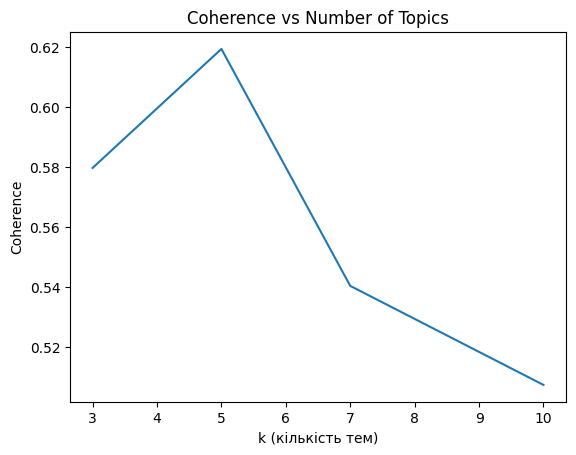


=== LDA ===
k=3, coherence=0.2945
k=5, coherence=0.2940
k=7, coherence=0.3028
k=10, coherence=0.3087


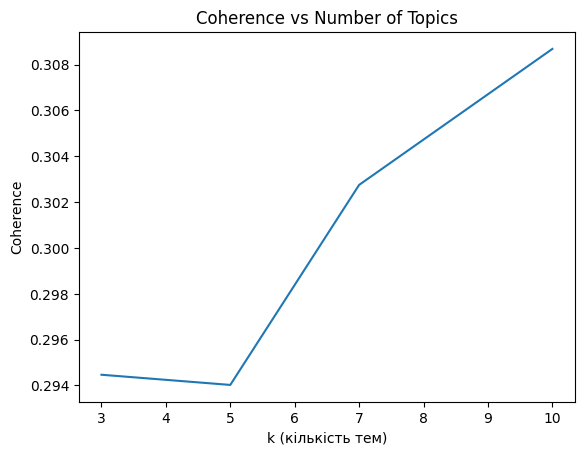

In [13]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD


def get_lsa_topics(vectorizer, svd_model, top_n=10):
    terms = vectorizer.get_feature_names_out()
    topics = []

    for comp in svd_model.components_:
        words = [terms[i] for i in comp.argsort()[-top_n:]]
        topics.append(words)

    return topics

coherence_scores = []
k_values = [3, 5, 7, 10]

texts_tokenized = [text.split() for text in df['text']]
dictionary = Dictionary(texts_tokenized)
vectorizer = pipeline_lsa.named_steps['tfidf']

print("\n=== LSA ===")
for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    X_lsa = svd.fit_transform(X)


    topics = get_lsa_topics(vectorizer, svd)

    cm = CoherenceModel(
        topics=topics,
        dictionary=dictionary,
        texts=texts_tokenized,
        coherence='c_v'
    )

    coherence = cm.get_coherence()
    coherence_scores.append(coherence)

    print(f"k={k}, coherence={coherence:.4f}")

plt.plot(k_values, coherence_scores)
plt.xlabel("k (кількість тем)")
plt.ylabel("Coherence")
plt.title("Coherence vs Number of Topics")
plt.show()

corpus = [dictionary.doc2bow(text) for text in texts_tokenized]
coherence_scores = []

print("\n=== LDA ===")
for k in k_values:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts_tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

    print(f"k={k}, coherence={coherence:.4f}")

plt.plot(k_values, coherence_scores)
plt.xlabel("k (кількість тем)")
plt.ylabel("Coherence")
plt.title("Coherence vs Number of Topics")
plt.show()

Для обох моделей було проведено оцінку якості тем за допомогою метрики coherence при різних значеннях кількості тем k.

Для моделі LSA найвище значення coherence (0.6195) досягнуто при k = 5, після чого спостерігається зниження якості тем при збільшенні кількості компонент. Це свідчить про те, що оптимальна кількість тем для LSA у даному корпусі становить 5.

Для моделі LDA значення coherence є значно нижчими (у межах 0.29–0.31) для всіх протестованих значень k. Незначне покращення спостерігається при k = 10, однак загальний рівень якості тем залишається низьким, що вказує на слабку узгодженість.

Порівняння результатів coherence показує, що модель LSA суттєво перевершує LDA за якістю тем для даного корпусу. Однак coherence не замінює ручну інтерпретацію, тому для остаточного висновку у Section 9. Manual interpretation та Section 10. “Bad topics” analysis здійснено ручний аналіз тем за top words та top documents.

# Section 12. Generate docs/audit_summary_lab8.md

In [14]:
report = """# Audit Summary — Lab 8 (Topic Modeling LSA / LDA)

## Розмір корпусу після фільтрації

Кількість документів: 837

## Протестовані моделі

Було протестовано дві моделі topic modeling:

1. LSA (Latent Semantic Analysis) на основі TF-IDF та TruncatedSVD
2. LDA (Latent Dirichlet Allocation) на основі CountVectorizer

## Протестовані k

Для обох моделей було протестовано різну кількість тем:
* k = 5
* k = 8

## Найкращі теми

Найкращі теми були отримані з моделі LSA:
1. Міжнародна політика (LSA, тема 0) — чітко визначена, ключові слова та документи повністю узгоджені
2. Валютний ринок (LSA, тема 2) — вузька економічна тематика без значного шуму
3. Енергетика (LSA, тема 3) — добре сформована тема з високою узгодженістю слів і документів

Ці теми є інтерпретованими, однорідними та легко піддаються аналізу.

## Найгірші теми

Найгірші теми спостерігаються в моделі LDA:
1. Тема 0 (Ринок нафти/економіка, LDA) — змішана (економіка + спорт + культура), не відповідає документам
2. Тема 2 (Загальні новини, LDA) — занадто загальна, містить службові слова (“йдеться”, “повідомленні”)
3. Тема 5 (Культура та війна, LDA) — поєднує культуру, війну та економіку

Ці теми є шумними, змішаними та погано інтерпретуються.

## Що їх зіпсувало

Основні причини низької якості тем:
* неоднорідність корпусу (деякі новини містять кілька сюжетів одночасно)
* недостатня фільтрація stop-слів і службової лексики
* неоптимальний вибір k

## Найкраща модель для даного корпусу

Для даного корпусу новин LSA виявилась кращою, оскільки тексти є неоднорідними та часто містять кілька сюжетів одночасно (політика та економіка, культура та економіка, спорт та політика). Завдяки матричному розкладу LSA краще захоплює глобальні залежності між словами та формує більш стабільні теми. Натомість LDA гірше справляється з такими даними через свою ймовірнісну природу, що призводить до розмитих і змішаних тем.

## Подальші кроки

Для покращення результатів можна:
* вдосконалити preprocessing (очистка, stop-words, нормалізація)
* підібрати оптимальне k (наприклад, через coherence score)
* додати біграми для кращого захоплення контексту
* обмежити корпус більш однорідними підтемами
"""

with open("audit_summary_lab8.md", "w", encoding="utf-8") as f:
    f.write(report)